In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
import tensorflow.random as tf_r
import keras_tuner
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras import Input
from scipy.optimize import curve_fit
from tensorflow.keras import layers
from tensorflow.keras.regularizers import L1L2

plt.rcParams['font.size'] = 14

np.random.seed(12345)
tf_r.set_seed(12345)

2026-05-17 10:46:37.057131: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-17 10:46:37.074920: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-17 10:46:37.702160: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-17 10:46:40.339587: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

I should try to train the CNN on a mixed dataset, then see how it generalize to others (with a single SNR) and see if regularization in this case helps.
It should improve the accuracy.   
With the previous analysis it didn't work because the structure of the problem was fundamentally different. Before, we were trying to see if a CNN generalize well on different pattern with reg (which should help preventing noise/pattern memorization), but reg helps in this only if the real data has the same underlying structure (NOT TRUE).

In [2]:
np.random.seed(12345)

jump = lambda drift1, drift2, std1, std2: [int(np.random.normal(drift1,std1)), int(np.random.normal(drift2, std2))]

def pattern(i,z1,z2,a1,a2):
    return [int(a1*np.sin((np.pi*i)/z1)), int(a2*np.sin((np.pi*i)/z2))]

In [3]:
def build_model(L, l, r, n_class=3, kernel_size=11, NF=5, stddev=0.05):
    
    input_shape = (L, 2)

    if r == 2:
        reg = tf.keras.regularizers.l2(l)
    elif r == 1:
        reg = tf.keras.regularizers.l1(l)
    elif r == 0:
        l2 = np.abs(1-l)
        reg = L1L2(l, l2)
        
    
    ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=stddev, seed=None)
    
        
    model = Sequential([
        Conv1D(filters=NF, kernel_size=kernel_size,
               kernel_initializer=ini,
               kernel_regularizer=reg,
               padding='same',
               activation='relu',
               input_shape=input_shape),
        MaxPooling1D(pool_size=2), #we need to catch a signal that is above the noise
        Conv1D(filters=NF * 2, kernel_size=5, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(n_class, activation='softmax')
    ])
    
    model.compile(
        loss=keras.losses.categorical_crossentropy,
        optimizer=tf.keras.optimizers.Adam(),
        metrics=['accuracy']
    )
    
    return model

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout


def build_model1(L, n_class=3, NF=5, kernel_size=11, l2_reg=0.2, stddev=0.05):

    input_shape = (L, 2)
    
    reg = tf.keras.regularizers.l2(l2_reg)
    ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=stddev, seed=None)
    
    model = Sequential([
        Conv1D(filters=NF, kernel_size=kernel_size,
               kernel_initializer=ini,
               kernel_regularizer=reg,
               padding='same',
               activation='relu',
               input_shape=input_shape),
        MaxPooling1D(pool_size=2), #we need to catch a signal that is above the noise
        Conv1D(filters=NF * 2, kernel_size=5, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(n_class, activation='softmax')
    ])
    
    model.compile(
        loss=keras.losses.categorical_crossentropy,
        optimizer=tf.keras.optimizers.Adam(),
        metrics=['accuracy']
    )
    
    return model

In [7]:
def Show_data2D(x):
    plt.plot(np.arange(L),x[0, :, 0], label='sample 0', c='r')
    plt.plot(np.arange(L,2*L),x[1, :, 0], label='sample 1', c='y')
    plt.plot(np.arange(2*L,3*L),x[2, :, 0], label='sample 2', c='b')
    plt.plot(np.arange(L),x[0, :, 1], c='r')
    plt.plot(np.arange(L,2*L),x[1, :, 1], c='y')
    plt.plot(np.arange(2*L,3*L),x[2, :, 1], c='b')
    
    plt.legend()
    plt.title("Time series")
    plt.show()

In [8]:
import numpy as np

np.random.seed(12345)

# -----------------------
# parameters
# -----------------------
SNRs = [0.1, 0.3, 1, 3, 10, 30]

N = 10000
L = 60
n_class = 3

bias = 5
sigma = 20
d = 11
Z1 = Z2 = d

bias1 = bias2 = bias
DX1 = DX2 = sigma

# -----------------------
# dataset containers
# -----------------------
x = np.zeros((N, L, 2), dtype=np.float32)
y = np.zeros(N, dtype=np.int32)

'''
# -----------------------
# generate dataset
# -----------------------
for i in range(N):

    # assign class
    y[i] = i % n_class

    # choose random SNR per sample
    snr = np.random.choice(SNRs)

    # amplitude depends on SNR
    A = np.sqrt((2 * (np.pi + 4) * d * snr/2) / np.pi**3) * sigma

    A1 = A
    A2 = A

    # build random walk signal
    if i>0: 
        jump0, jump1 = jump(bias1, bias2, DX1, DX2)
        x[i][0][0] = x[i-1][-1][0] + jump0 
        x[i][0][1] = x[i-1][-1][1] + jump1
    
    for j in range(1, L):
        dx1, dx2 = jump(bias, bias, sigma, sigma)
        x[i][j][0] = x[i][j-1][0] + dx1
        x[i][j][1] = x[i][j-1][1] + dx2

    # inject pattern for classes 1 and 2
    if y[i] > 0:
        j0 = np.random.randint(0, L - d)
        sign = 3 - 2 * y[i]

        for j in range(d):
            p1, p2 = pattern(j, d, d, A1, A2)
            x[i][j0 + j][0] += sign * p1
            x[i][j0 + j][1] += sign * p2


# -----------------------
# one-hot labels
# -----------------------
y_oh = np.eye(n_class)[y]


# -----------------------
# train/val split
# -----------------------
N_train = int(0.8 * N)

x_train, x_val = x[:N_train], x[N_train:]
y_train, y_val = y_oh[:N_train], y_oh[N_train:]


# -----------------------
# normalization (global per sample)
# -----------------------
xm_train = x_train.mean(axis=1, keepdims=True)
std_train = x_train.std(axis=1, keepdims=True) + 1e-8

x_train = (x_train - xm_train) / std_train

xm_val = x_val.mean(axis=1, keepdims=True)
std_val = x_val.std(axis=1, keepdims=True) + 1e-8

x_val = (x_val - xm_val) / std_val


# -----------------------
# save
# -----------------------
np.save("x_train_mixed.npy", x_train)
np.save("y_train_mixed.npy", y_train)
np.save("x_val_mixed.npy", x_val)
np.save("y_val_mixed.npy", y_val)
'''

'\n# -----------------------\n# generate dataset\n# -----------------------\nfor i in range(N):\n\n    # assign class\n    y[i] = i % n_class\n\n    # choose random SNR per sample\n    snr = np.random.choice(SNRs)\n\n    # amplitude depends on SNR\n    A = np.sqrt((2 * (np.pi + 4) * d * snr/2) / np.pi**3) * sigma\n\n    A1 = A\n    A2 = A\n\n    # build random walk signal\n    if i>0: \n        jump0, jump1 = jump(bias1, bias2, DX1, DX2)\n        x[i][0][0] = x[i-1][-1][0] + jump0 \n        x[i][0][1] = x[i-1][-1][1] + jump1\n\n    for j in range(1, L):\n        dx1, dx2 = jump(bias, bias, sigma, sigma)\n        x[i][j][0] = x[i][j-1][0] + dx1\n        x[i][j][1] = x[i][j-1][1] + dx2\n\n    # inject pattern for classes 1 and 2\n    if y[i] > 0:\n        j0 = np.random.randint(0, L - d)\n        sign = 3 - 2 * y[i]\n\n        for j in range(d):\n            p1, p2 = pattern(j, d, d, A1, A2)\n            x[i][j0 + j][0] += sign * p1\n            x[i][j0 + j][1] += sign * p2\n\n\n# ------

In [9]:
Show_data2D(x_train)

NameError: name 'x_train' is not defined

In [20]:
BATCH_SIZE = 200
EPOCHS = 250 # TO CHANGE


fnamex='x_train_mixed.npy'
fnamey='y_train_mixed.npy'

x_train = np.load(fnamex)
y_train = np.load(fnamey)

fxv='x_val_mixed.npy'
fyv='y_val_mixed.npy'

x_val = np.load(fxv)
y_val = np.load(fyv)


model = build_model1(L)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True
)

fit = model.fit(x_train, y_train,
                batch_size=BATCH_SIZE,
                epochs=EPOCHS,
                validation_data=(x_val, y_val),
                verbose=False,
                shuffle=True,
                callbacks=[early_stop])

# Prendi il MASSIMO, non l'ultimo
acc_param = max(fit.history['val_accuracy'])

/home/laraf/jup-env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
acc_param

0.5529999732971191

In [22]:
ACC = []
test_SNR = [0.05, 0.15, 0.5, 1.5, 5, 15] # half
pat_par_test = []

for SNR in test_SNR:
    A_1 = (2*(np.pi + 4)*d*SNR / np.pi**3)**0.5 * sigma
    A_2 = (2*(np.pi + 4)*d*SNR / np.pi**3)**0.5 * sigma
    c = 0
    pat_par_test.append((A_1, sigma, bias, A_2, sigma, bias, c))

for par in pat_par_test:
    A1, DX1, bias1, A2, DX2, bias2, c = par
    str0 = f'L{L}_Z1({Z1})_Z2({Z2})_A1({A1})_A2({A2})_DX({DX1,DX2})_bias({bias1,bias2})_N{N}_ver{c}'
    
    fnamex='DATA_REG/x_ts'+str0+'.npy'
    fnamey='DATA_REG/y_ts'+str0+'.npy'

    x_train = np.load(fnamex)
    y_train = np.load(fnamey)

    fxv='DATA_REG/x_vs'+str0+'.npy'
    fyv='DATA_REG/y_vs'+str0+'.npy'

    x_val = np.load(fxv)
    y_val = np.load(fyv)

    x_test = np.concatenate((x_train, x_val))
    y_test = np.concatenate((y_train, y_val)).astype(np.int64)

    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    ACC.append(acc)
    
        
        
        

In [23]:
import pandas as pd
import seaborn as sns

tr_SNR = [0.1, 0.3, 1, 3, 10, 30]
test_SNR = [0.1, 0.3, 1, 3, 10, 30]

ACC = pd.DataFrame(ACC)

ACC

np.save("acc_mix_noreg", ACC)

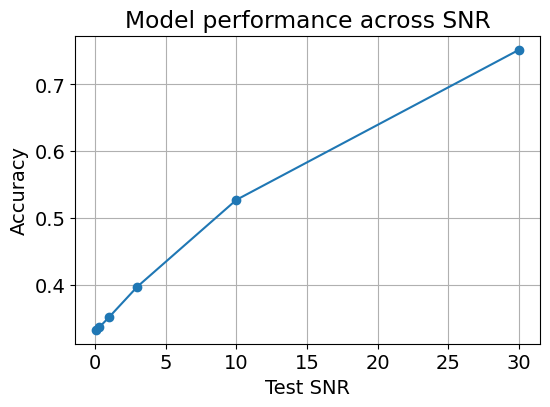

In [24]:
plt.figure(figsize=(6,4))
plt.plot(test_SNR, ACC, marker='o')

#plt.xscale('log')  # optional but often useful for SNR
plt.xlabel("Test SNR")
plt.ylabel("Accuracy")
plt.title("Model performance across SNR")
plt.grid(True)
plt.show()

# does it make sense to compare with mean across rows (horizontal) from Giacomo's heatmap?

In [12]:
BATCH_SIZE = 200
EPOCHS = 250 # TO CHANGE


lambdas = [0.5, 0.05, 0.005, 0.0005, 0.00005]
rs = [0, 1, 2]

acc_train = []

x_train = np.load("x_train_mixed.npy")
y_train = np.load("y_train_mixed.npy")
x_val = np.load("x_val_mixed.npy")
y_val = np.load("y_val_mixed.npy")

models = []
for r in rs:
    for l in lambdas:
    
        print(f"  r={r}, lambda={l}")
    
        model = build_model(L, l, r, n_class=n_class)
    
        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=15,
            restore_best_weights=True
        )
    
        history = model.fit(
            x_train, y_train,
            batch_size=BATCH_SIZE,
            epochs=EPOCHS,
            validation_data=(x_val, y_val),
            verbose=False,
            shuffle=True,
            callbacks=[early_stop]
        )
        models.append(model)
    
        acc_train.append(
            max(history.history['val_accuracy'])
        )

  r=0, lambda=0.5
  r=0, lambda=0.05
  r=0, lambda=0.005
  r=0, lambda=0.0005
  r=0, lambda=5e-05
  r=1, lambda=0.5
  r=1, lambda=0.05
  r=1, lambda=0.005
  r=1, lambda=0.0005
  r=1, lambda=5e-05
  r=2, lambda=0.5
  r=2, lambda=0.05
  r=2, lambda=0.005
  r=2, lambda=0.0005
  r=2, lambda=5e-05


In [13]:
test_SNR = [0.05, 0.15, 0.5, 1.5, 5, 15] # half

pat_par_test = []

for SNR in test_SNR:
    A_1 = (2*(np.pi + 4)*d*SNR / np.pi**3)**0.5 * sigma
    A_2 = (2*(np.pi + 4)*d*SNR / np.pi**3)**0.5 * sigma
    c = 0
    pat_par_test.append((A_1, sigma, bias, A_2, sigma, bias, c))
    
ACC = []   # store everything

for m in models:
    accuracies = []
    for i, par in enumerate(pat_par_test):
        A1, DX1, bias1, A2, DX2, bias2, c = par
        str0 = f'L{L}_Z1({Z1})_Z2({Z2})_A1({A1})_A2({A2})_DX({DX1,DX2})_bias({bias1,bias2})_N{N}_ver{c}'
        
        fnamex='DATA_REG/x_ts'+str0+'.npy'
        fnamey='DATA_REG/y_ts'+str0+'.npy'
    
        x_train = np.load(fnamex)
        y_train = np.load(fnamey)
    
        fxv='DATA_REG/x_vs'+str0+'.npy'
        fyv='DATA_REG/y_vs'+str0+'.npy'
    
        x_val = np.load(fxv)
        y_val = np.load(fyv)
        
        x_test = np.concatenate((x_train, x_val))
        y_test = np.concatenate((y_train, y_val)).astype(np.int64)

        loss, acc = m.evaluate(x_test, y_test, verbose=0)
        accuracies.append(acc)
        print(i)

    ACC.append(accuracies)

0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5


In [14]:
ACC = pd.DataFrame(ACC)
np.save("acc_mixed", ACC)

In [15]:
ACC

,0,1,2,3,4,5
0,0.3338,0.3350,0.3340,0.3340,0.3360,0.3373
1,0.3297,0.3344,0.3468,0.3799,0.4901,0.7166
2,0.3312,0.3403,0.3452,0.3819,0.5089,0.7436
3,0.3327,0.3371,0.3489,0.3824,0.5129,0.7614
4,0.3295,0.3353,0.3421,0.3646,0.4548,0.6621
5,0.3313,0.3303,0.3474,0.3582,0.3963,0.4456
6,0.3313,0.3410,0.3438,0.3770,0.5031,0.7521
7,0.3311,0.3376,0.3511,0.3893,0.5326,0.7626
8,0.3306,0.3409,0.3458,0.3830,0.4973,0.6854
9,0.3333,0.3349,0.3506,0.3891,0.5441,0.7811


In [19]:
acc_r1 = ACC[0:5].T
acc_r2 = ACC[5:10].T
acc_r3 = ACC[10:15].T

SNRs = [0.1, 0.3, 1, 3, 10, 30]

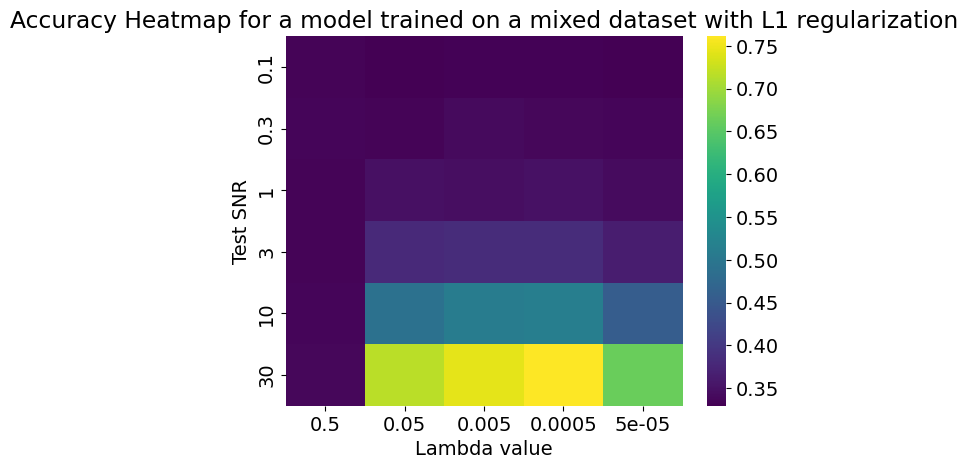

In [21]:
import seaborn as sns
sns.heatmap(
    acc_r1,
    fmt=".3f",
    cmap="viridis",
    xticklabels=lambdas,
    yticklabels=SNRs
)

plt.xlabel("Lambda value")
plt.ylabel("Test SNR")
plt.title("Accuracy Heatmap for a model trained on a mixed dataset with L1 regularization")
plt.show()

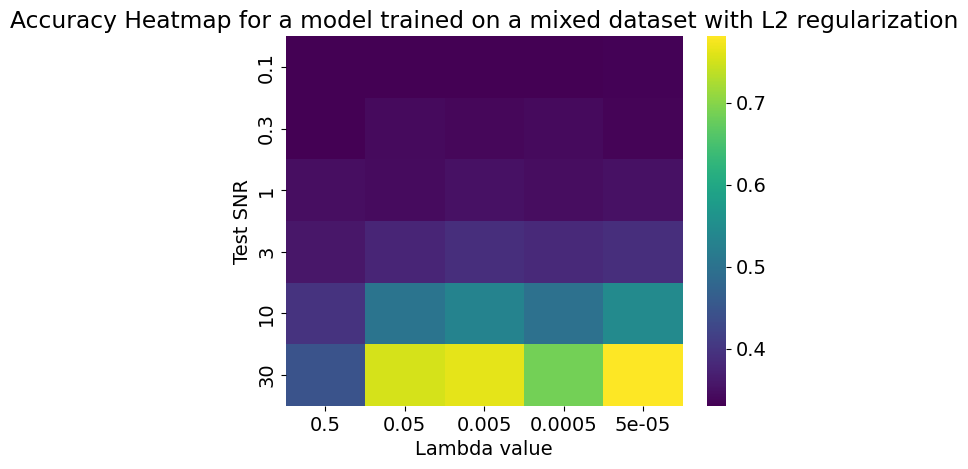

In [22]:
sns.heatmap(
    acc_r2,
    fmt=".3f",
    cmap="viridis",
    xticklabels=lambdas,
    yticklabels=SNRs
)

plt.xlabel("Lambda value")
plt.ylabel("Test SNR")
plt.title("Accuracy Heatmap for a model trained on a mixed dataset with L2 regularization")
plt.show()

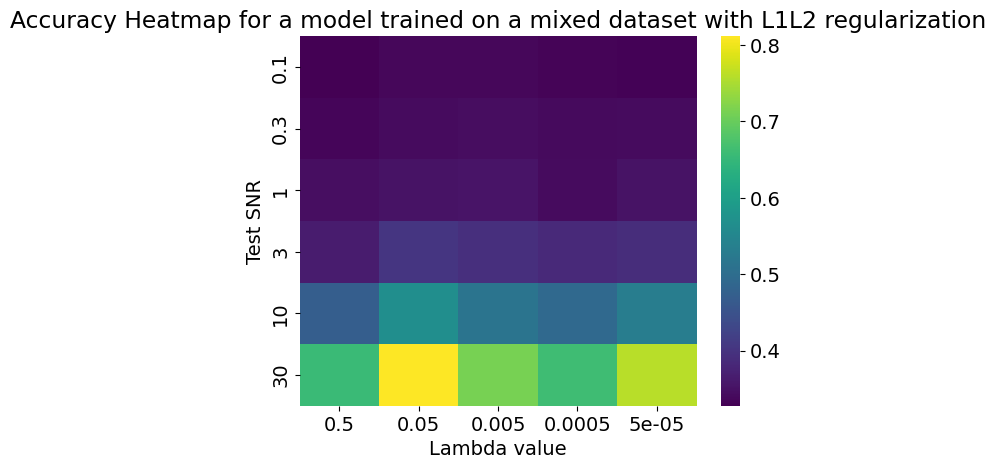

In [23]:
sns.heatmap(
    acc_r3,
    fmt=".3f",
    cmap="viridis",
    xticklabels=lambdas,
    yticklabels=SNRs
)

plt.xlabel("Lambda value")
plt.ylabel("Test SNR")
plt.title("Accuracy Heatmap for a model trained on a mixed dataset with L1L2 regularization")
plt.show()